In [1]:
import pandas as pd 

chip_companies_financials = pd.read_csv("chip_companies_financials.csv")
chip_companies_financials.head()

,year,company_name,ticker,country_iso3,segment,revenue_usd_bn,operating_margin_pct,operating_income_usd_bn,rd_spend_usd_bn,capex_usd_bn
0,2010,TSMC,TSM,TWN,foundry,13.42,36.9,4.95,1.07,6.04
1,2011,TSMC,TSM,TWN,foundry,16.32,42.8,6.99,1.31,7.35
2,2012,TSMC,TSM,TWN,foundry,17.56,36.1,6.34,1.40,7.90
3,2013,TSMC,TSM,TWN,foundry,21.36,39.1,8.34,1.71,9.61
4,2014,TSMC,TSM,TWN,foundry,23.93,37.4,8.96,1.91,10.77



    <h4>Step 1: Define Business Objective</h4>
    <p><strong>Objective:</strong> Segment semiconductor companies into distinct groups based on their financial performance and investment behavior to uncover hidden business patterns and strategic differences.</strong></p>

<section id="step-4">
    <h4>Step 2: Feature Selection</h4>
    <p><strong>Core Question:</strong> Which features should define the similarity between companies?</p>
</section>

In [3]:
features = [
    "revenue_usd_bn",
    "operating_margin_pct",
    "operating_income_usd_bn",
    "rd_spend_usd_bn",
    "capex_usd_bn"
]

X = chip_companies_financials[features]

In [4]:
X.head()

,revenue_usd_bn,operating_margin_pct,operating_income_usd_bn,rd_spend_usd_bn,capex_usd_bn
0,13.42,36.9,4.95,1.07,6.04
1,16.32,42.8,6.99,1.31,7.35
2,17.56,36.1,6.34,1.40,7.90
3,21.36,39.1,8.34,1.71,9.61
4,23.93,37.4,8.96,1.91,10.77


In [5]:
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 617 entries, 0 to 616
Data columns (total 5 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   revenue_usd_bn           617 non-null    float64
 1   operating_margin_pct     617 non-null    float64
 2   operating_income_usd_bn  617 non-null    float64
 3   rd_spend_usd_bn          617 non-null    float64
 4   capex_usd_bn             617 non-null    float64
dtypes: float64(5)
memory usage: 24.2 KB


<section id="step-5">
    <h4>Step 3: Exploratory Analysis of Selected Features</h4>
    <p><strong>Objective:</strong> Understand the distribution, relationships, and potential issues in the features before clustering.</p>
</section>

<div style="background: #1f2937; color: #f9fafb; padding: 6px 12px; border-radius: 6px; display: inline-block;">
    <h3 style="margin: 0; font-size: 0.95rem; font-weight: 500; letter-spacing: 0.3px;">3.1 Summary Statistics</h3>
</div>

In [6]:
X.describe().T

,count,mean,std,min,25%,50%,75%,max
revenue_usd_bn,617.0,14.354392,21.474730,0.0,3.43,7.15,15.69,250.68
operating_margin_pct,617.0,30.335818,11.517675,3.3,21.20,30.80,39.60,64.20
operating_income_usd_bn,617.0,4.505154,9.884108,0.0,1.08,2.08,4.90,155.25
rd_spend_usd_bn,617.0,1.963225,4.101473,0.0,0.44,0.97,1.89,62.67
capex_usd_bn,617.0,3.117180,6.031188,0.0,0.39,1.03,2.38,50.96


<div style="background: #1f2937; color: #f9fafb; padding: 6px 12px; border-radius: 6px; display: inline-block; margin-bottom: 12px;">
    <h3 style="margin: 0; font-size: 0.95rem; font-weight: 500; letter-spacing: 0.3px;">3.2 Check for Outliers (Boxplots)</h3>
</div>

<p><strong>Why?</strong> Outliers can pull cluster centers toward them because K-Means uses Euclidean distances, heavily distorting the final groupings.</p>

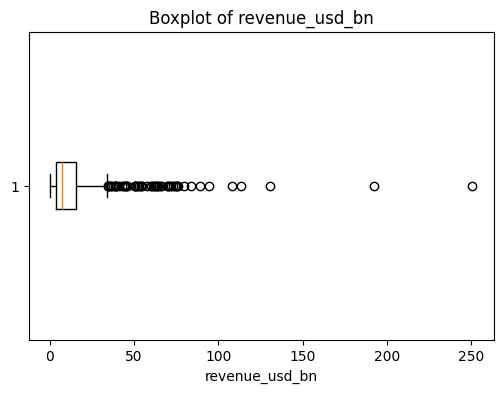

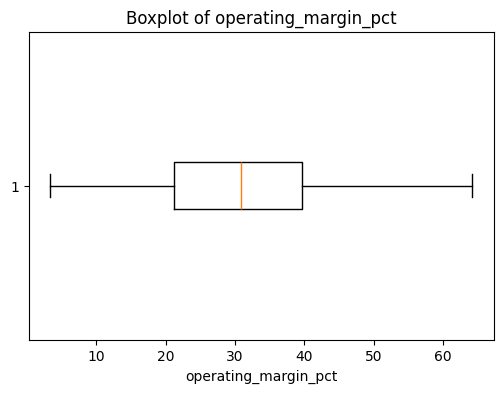

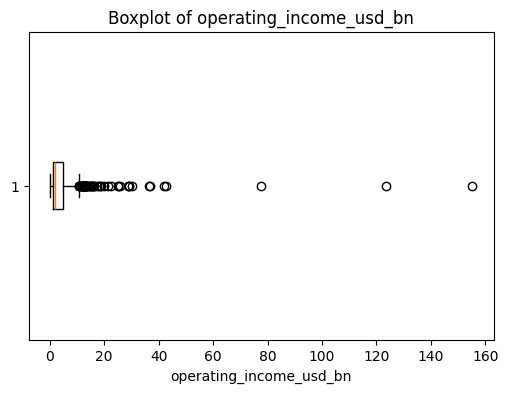

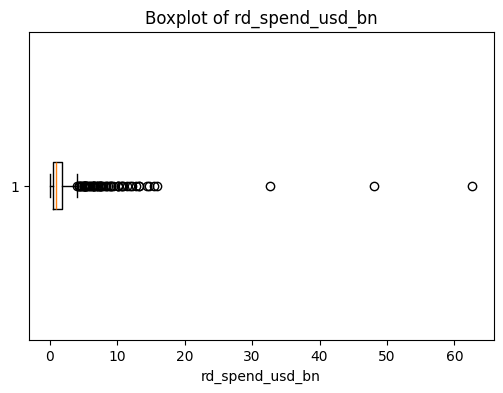

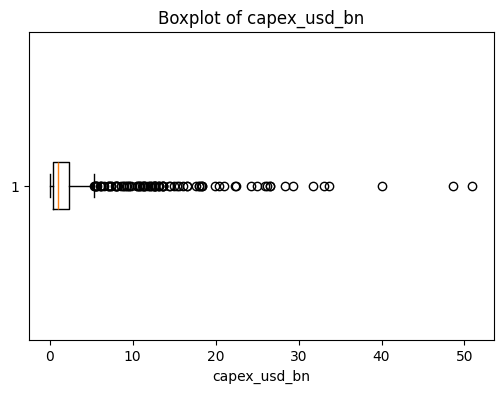

In [7]:
import matplotlib.pyplot as plt

for col in X.columns:
    plt.figure(figsize=(6,4))
    plt.boxplot(X[col], vert=False)
    plt.title(f"Boxplot of {col}")
    plt.xlabel(col)
    plt.show()

<div style="background: #1f2937; color: #f9fafb; padding: 6px 12px; border-radius: 6px; display: inline-block; margin-bottom: 12px;">
    <h3 style="margin: 0; font-size: 0.95rem; font-weight: 500; letter-spacing: 0.3px;">3.3 Distribution of Features</h3>
</div>

<p><strong>Objective:</strong> Examine the skewness and modality of each feature (e.g., using histograms or density plots) to determine if transformations are needed before clustering.</p>

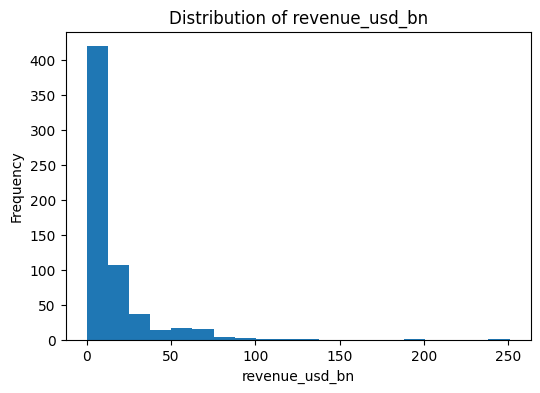

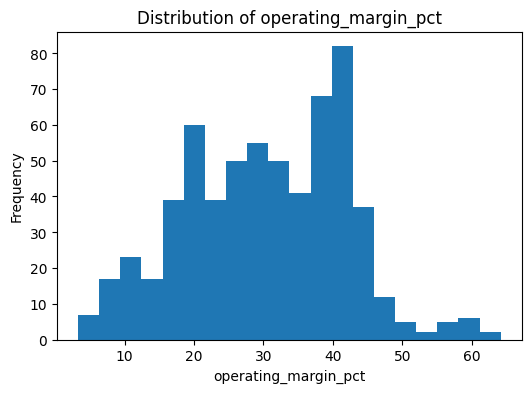

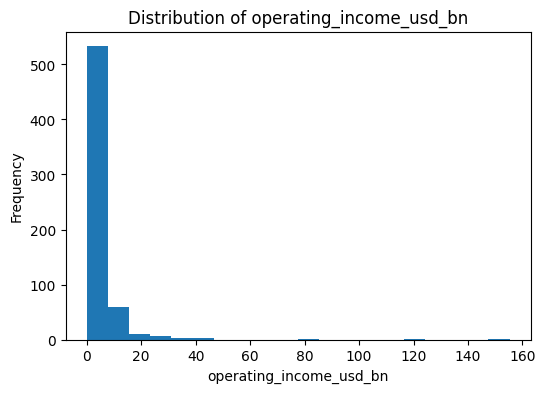

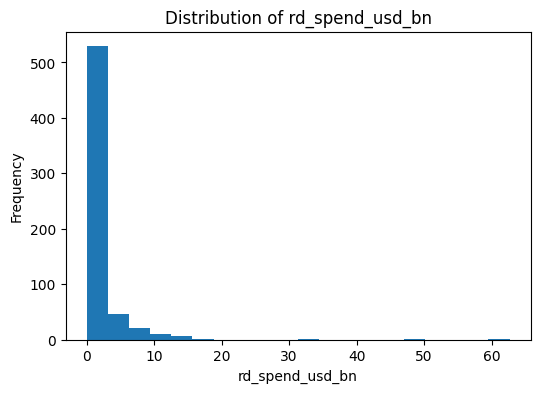

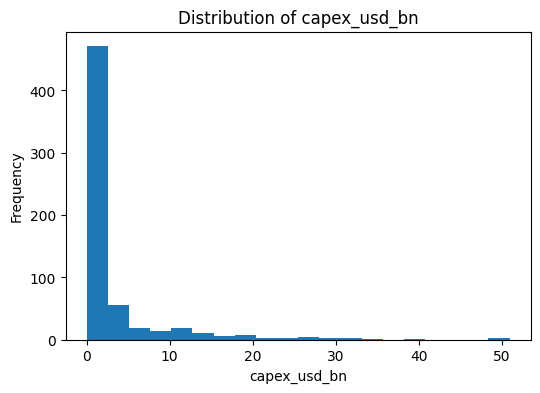

In [8]:
for col in X.columns:
    plt.figure(figsize=(6,4))
    plt.hist(X[col], bins=20)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

<div style="background: #1f2937; color: #f9fafb; padding: 6px 12px; border-radius: 6px; display: inline-block; margin-bottom: 12px;">
    <h3 style="margin: 0; font-size: 0.95rem; font-weight: 500; letter-spacing: 0.3px;">Observation: Financial Variables are Highly Right-Skewed</h3>
</div>

<p>The financial variables (<code>revenue_usd_bn</code>, <code>operating_income_usd_bn</code>, <code>rd_spend_usd_bn</code>, and <code>capex_usd_bn</code>) exhibit strong positive skewness, indicating that a small number of companies have exceptionally large financial values while most companies operate at much smaller scales.</p>

<p><strong>Impact:</strong> Such skewed distributions can disproportionately influence distance-based algorithms like K-Means.</p>

<p><strong>Recommendation:</strong> Applying a log transformation (e.g., <code>log1p</code>) before clustering can help reduce the impact of extreme values and produce more balanced clusters.</p>

<div style="background: #1f2937; color: #f9fafb; padding: 6px 12px; border-radius: 6px; display: inline-block; margin-bottom: 12px;">
    <h3 style="margin: 0; font-size: 0.95rem; font-weight: 500; letter-spacing: 0.3px;">3.4 Correlation Analysis</h3>
</div>

<p><strong>Objective:</strong> Analyze the pairwise correlations between the selected features (e.g., using a correlation heatmap) to identify multicollinearity.</p>

<p><strong>Why?</strong> Highly correlated features can artificially inflate the importance of certain business dimensions in distance-based clustering metrics, leading to biased groups.</p>

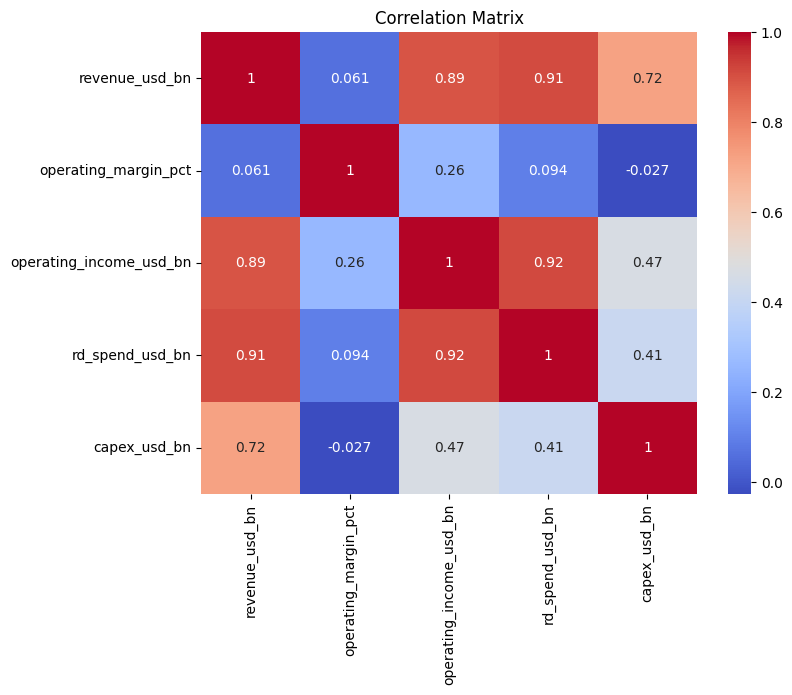

In [9]:
import seaborn as sns

plt.figure(figsize=(8,6))
sns.heatmap(X.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

<div style="background: #1f2937; color: #f9fafb; padding: 6px 12px; border-radius: 6px; display: inline-block; margin-bottom: 12px;">
    <h3 style="margin: 0; font-size: 0.95rem; font-weight: 500; letter-spacing: 0.3px;">Observation: Correlation Patterns</h3>
</div>

<p><strong>Strong Positive Correlations (0.89–0.92):</strong> <code>Revenue</code>, <code>Operating Income</code>, and <code>R&D Spending</code> exhibit strong positive correlations, indicating that companies with higher revenues generally generate higher operating income and invest more heavily in research and development.</p>

<p><strong>Weak to Moderate Correlations:</strong> In contrast, <code>Operating Margin</code> and <code>CAPEX</code> show only weak to moderate correlations with the remaining variables, suggesting they capture different, independent aspects of a company's business performance and investment strategy.</p>

<section id="step-5">
    <h4>Step 4 : Data Pre processing for clustering </h4>
</section>

<div style="background: #1f2937; color: #f9fafb; padding: 6px 12px; border-radius: 6px; display: inline-block;">
    <h3 style="margin: 0; font-size: 0.95rem; font-weight: 500; letter-spacing: 0.3px;">4.1 Apply Log Transformation</h3>
</div>

In [10]:
import numpy as np

X_log = X.copy()

log_columns = [
    "revenue_usd_bn",
    "operating_income_usd_bn",
    "rd_spend_usd_bn",
    "capex_usd_bn"
]

X_log[log_columns] = np.log1p(X_log[log_columns])

<div style="background: #1f2937; color: #f9fafb; padding: 6px 12px; border-radius: 6px; display: inline-block;">
    <h3 style="margin: 0; font-size: 0.95rem; font-weight: 500; letter-spacing: 0.3px;">4.2 Check the distributions again </h3>
</div>

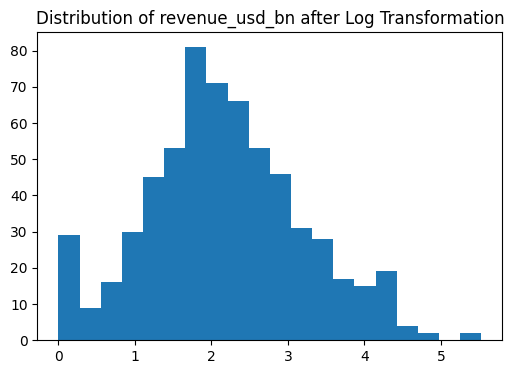

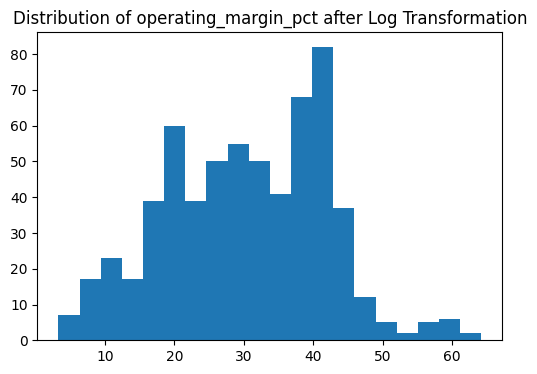

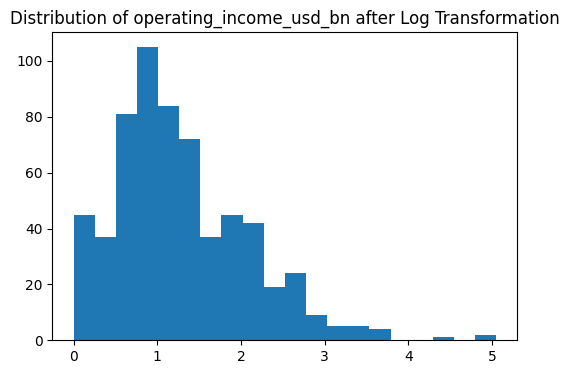

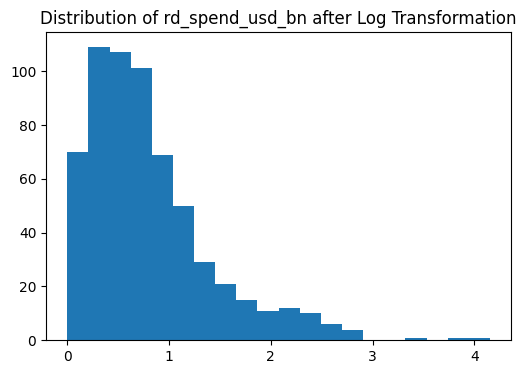

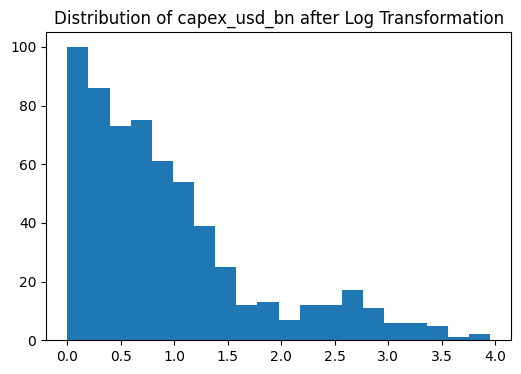

In [11]:
import matplotlib.pyplot as plt

for col in X_log.columns:
    plt.figure(figsize=(6,4))
    plt.hist(X_log[col], bins=20)
    plt.title(f"Distribution of {col} after Log Transformation")
    plt.show()

<div style="background: #1f2937; color: #f9fafb; padding: 6px 12px; border-radius: 6px; display: inline-block; margin-bottom: 12px;">
    <h3 style="margin: 0; font-size: 0.95rem; font-weight: 500; letter-spacing: 0.3px;">4.3 Standardize the Features</h3>
</div>

<p><strong>Action:</strong> Standardize all features to have a mean of 0 and a standard deviation of 1 using <code>StandardScaler</code>.</p>

<p><strong>Why?</strong> K-Means relies heavily on Euclidean distance metrics. If features remain on drastically different scales, variables with larger absolute numeric ranges will dominate the distance calculations and skew the final cluster assignments. Standardizing ensures every feature contributes equally to the similarity definition.</p>

In [12]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_log)

<div style="background: #1f2937; color: #f9fafb; padding: 6px 12px; border-radius: 6px; display: inline-block;">
    <h3 style="margin: 0; font-size: 0.95rem; font-weight: 500; letter-spacing: 0.3px;">4.4  Verify scaling  </h3>
</div>

In [13]:
X_scaled.mean(axis=0)

array([ 3.68514871e-16,  4.37611409e-16, -1.84257436e-16,  9.21287178e-17,
        0.00000000e+00])

In [14]:
X_scaled.std(axis=0)

array([1., 1., 1., 1., 1.])

<h4>Step 5: Determine the Optimal Number of Clusters</h4>

<p>Since K-Means requires you to specify the number of clusters (k), we shouldn't guess it. We will use:</p>

<ul>
    <li>Elbow Method</li>
    <li>Silhouette Score</li>
</ul>

<div style="background: #1f2937; color: #f9fafb; padding: 6px 12px; border-radius: 6px; display: inline-block;">
    <h3 style="margin: 0; font-size: 0.95rem; font-weight: 500; letter-spacing: 0.3px;">5.1 Elbow method</h3>
</div>

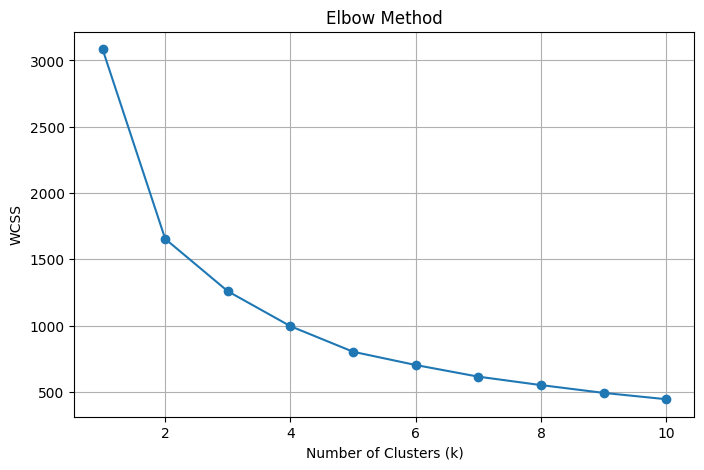

In [15]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

for k in range(1, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.grid(True)
plt.show()

<div style="background: #1f2937; color: #f9fafb; padding: 6px 12px; border-radius: 6px; display: inline-block;">
    <h3 style="margin: 0; font-size: 0.95rem; font-weight: 500; letter-spacing: 0.3px;">5.2 Silhouette score</h3>
</div>

In [16]:
from sklearn.metrics import silhouette_score

scores = []

for k in range(2,11):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = model.fit_predict(X_scaled)

    score = silhouette_score(X_scaled, labels)

    scores.append(score)

    print(f"k = {k}, Silhouette Score = {score:.3f}")

k = 2, Silhouette Score = 0.445
k = 3, Silhouette Score = 0.293
k = 4, Silhouette Score = 0.307
k = 5, Silhouette Score = 0.348
k = 6, Silhouette Score = 0.340
k = 7, Silhouette Score = 0.342
k = 8, Silhouette Score = 0.328
k = 9, Silhouette Score = 0.316
k = 10, Silhouette Score = 0.329


<section id="step-5">
    <h4>Step 6 :Train the Final K means Model </h4>
</section>

In [17]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)

chip_companies_financials["Cluster"] = clusters

<div style="background: #1f2937; color: #f9fafb; padding: 6px 12px; border-radius: 6px; display: inline-block;">
    <h3 style="margin: 0; font-size: 0.95rem; font-weight: 500; letter-spacing: 0.3px;">6.1 Check the number of companies in each cluster</h3>
</div>

In [18]:
chip_companies_financials["Cluster"].value_counts()

Cluster
1    449
0    168
Name: count, dtype: int64

<h4>Step 7: Profile the Clusters </h4>

<p>Now this answers the core business question:</p>

<blockquote>
    "What makes Cluster 0 different from Cluster 1?"
</blockquote>

In [19]:
cluster_profile = chip_companies_financials.groupby("Cluster")[features].mean().round(2)

cluster_profile

,revenue_usd_bn,operating_margin_pct,operating_income_usd_bn,rd_spend_usd_bn,capex_usd_bn
Cluster,,,,,
0,37.43,32.00,12.13,5.21,8.91
1,5.72,29.71,1.65,0.75,0.95




<h4>Cluster 0</h4>
<p><strong>Characteristics:</strong></p>
<ul>
    <li>High Revenue</li>
    <li>High Operating Income</li>
    <li>High R&D Investment</li>
    <li>High CAPEX</li>
    <li>Similar Profit Margin</li>
</ul>
<p><strong>Strategic Label:</strong> Large Established Semiconductor Companies</p>
<p><strong>Examples (Likely assignments):</strong> NVIDIA, Intel, TSMC, Samsung, Qualcomm, Broadcom</p>

<h4>Cluster 1</h4>
<p><strong>Characteristics:</strong></p>
<ul>
    <li>Lower Revenue</li>
    <li>Lower Operating Income</li>
    <li>Lower R&D</li>
    <li>Lower CAPEX</li>
    <li>Comparable Margins</li>
</ul>
<p><strong>Strategic Label:</strong> Small & Mid-sized Semiconductor Companies</p>

<h4>Key Observation</h4>

<p>K-Means successfully segmented semiconductor companies into two distinct groups primarily based on their financial scale rather than operational efficiency.</p>

<ul>
    <li><strong>Cluster 0</strong> consists of large, established companies with substantially higher revenue, operating income, R&D expenditure, and capital investment.</li>
    <li><strong>Cluster 1</strong> contains smaller and mid-sized companies with lower financial metrics.</li>
</ul>

<p><strong>Strategic Insight:</strong> Interestingly, both clusters exhibit similar operating margins, indicating that profitability efficiency remains relatively consistent regardless of company size.</p>

<section id="step-5">
    <h4>Step 8 : Visualize the clusters (PCA) </h4>
</section>

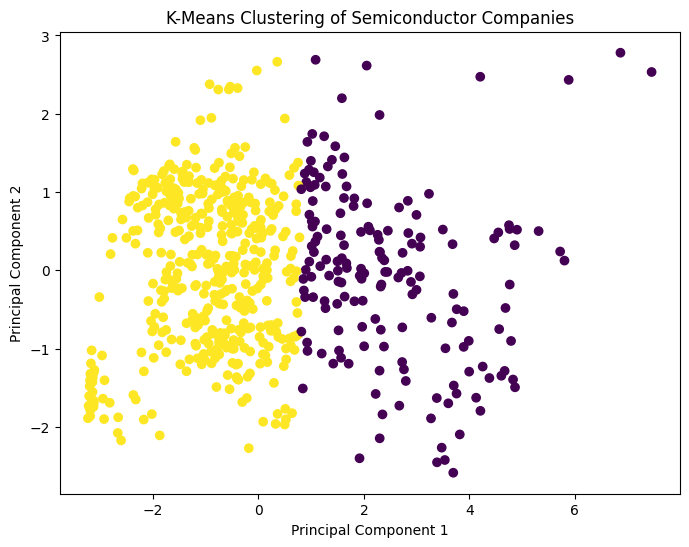

In [21]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=clusters
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("K-Means Clustering of Semiconductor Companies")

plt.show()

<h4>Business Insights</h4>

<p><strong>Insight 1: Natural Segmentation</strong><br>
K-Means clustering successfully identified two distinct groups of semiconductor companies, indicating that the industry naturally segments into companies with different financial scales and investment capabilities.</p>

<p><strong>Insight 2: Financial Scale Drives Segmentation</strong><br>
The primary factor differentiating the clusters is financial scale. Companies in Cluster 0 generate significantly higher revenue, operating income, R&D expenditure, and capital expenditure than those in Cluster 1.</p>

<p><strong>Insight 3: Investment Patterns</strong><br>
Companies in Cluster 0 invest substantially more in research & development (R&D) and capital expenditure (CAPEX), suggesting a stronger focus on innovation and long-term manufacturing expansion.</p>

<p><strong>Insight 4: Operational Efficiency</strong><br>
Despite major differences in company size, both clusters exhibit similar operating margins (approximately 30–32%), indicating that operational efficiency remains relatively consistent across both large and smaller semiconductor firms.</p>

<p><strong>Insight 5: Strategic Classification</strong><br>
The clustering results classify companies into large established market leaders and small-to-mid-sized companies, providing a useful framework for competitive benchmarking and strategic analysis.</p>